<a href="https://colab.research.google.com/github/matheusmello-o/turnover-optmization/blob/main/turnover.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = 'https://github.com/matheusmello-o/turnover-optmization/raw/main/files/Base_dados%20-%20Rotatividade%20RH.xlsx'


df = pd.read_excel(url, engine='openpyxl')
df.columns = df.columns.str.lower()
df.head()

,data_contratacao,data_desligamento,meses_de_servico,idade,pontuacao_desempenho,satisfacao_trabalho,nivel_cargo,salario,horas_extras,desligamento
0,2024-02-14,NaT,3,24,2.066788,2.043644,Pleno,4994.41,15.465241,0
1,2023-11-16,2024-05-14,6,43,3.256257,1.711719,Sênior,8798.34,19.036627,1
2,2023-11-16,NaT,6,45,4.827732,3.480214,Sênior,8891.02,13.326408,0
3,2023-05-20,NaT,12,31,1.453944,1.617558,Pleno,7606.22,14.209663,0
4,2022-07-24,NaT,22,37,2.088917,2.763390,Sênior,9236.03,11.059687,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   data_contratacao      650 non-null    datetime64[ns]
 1   data_desligamento     144 non-null    datetime64[ns]
 2   meses_de_servico      650 non-null    int64         
 3   idade                 650 non-null    int64         
 4   pontuacao_desempenho  650 non-null    float64       
 5   satisfacao_trabalho   650 non-null    float64       
 6   nivel_cargo           650 non-null    object        
 7   salario               650 non-null    float64       
 8   horas_extras          650 non-null    float64       
 9   desligamento          650 non-null    int64         
dtypes: datetime64[ns](2), float64(4), int64(3), object(1)
memory usage: 50.9+ KB


In [ ]:
df.describe()

,data_contratacao,data_desligamento,meses_de_servico,idade,pontuacao_desempenho,satisfacao_trabalho,salario,horas_extras,desligamento
count,650,144,650.000000,650.000000,650.000000,650.000000,650.000000,650.000000,650.000000
mean,2022-10-31 06:38:46.153846272,2024-05-14 00:00:00,18.690769,28.349231,3.027463,2.940577,6131.587062,10.098864,0.221538
min,2021-06-29 00:00:00,2024-05-14 00:00:00,3.000000,18.000000,1.000242,1.002868,2004.500000,0.003734,0.000000
25%,2022-02-24 00:00:00,2024-05-14 00:00:00,10.000000,22.000000,1.988753,1.968571,4023.752500,4.978000,0.000000
50%,2022-10-22 00:00:00,2024-05-14 00:00:00,19.000000,27.000000,3.058911,2.923458,5562.950000,9.413546,0.000000
75%,2023-07-19 00:00:00,2024-05-14 00:00:00,27.000000,33.000000,4.022709,3.964356,7814.480000,14.749310,0.000000
max,2024-02-14 00:00:00,2024-05-14 00:00:00,35.000000,49.000000,4.992102,4.999415,11957.290000,41.638350,1.000000
std,NaN,NaN,9.652262,8.014983,1.174226,1.148514,2689.075566,6.242406,0.415602


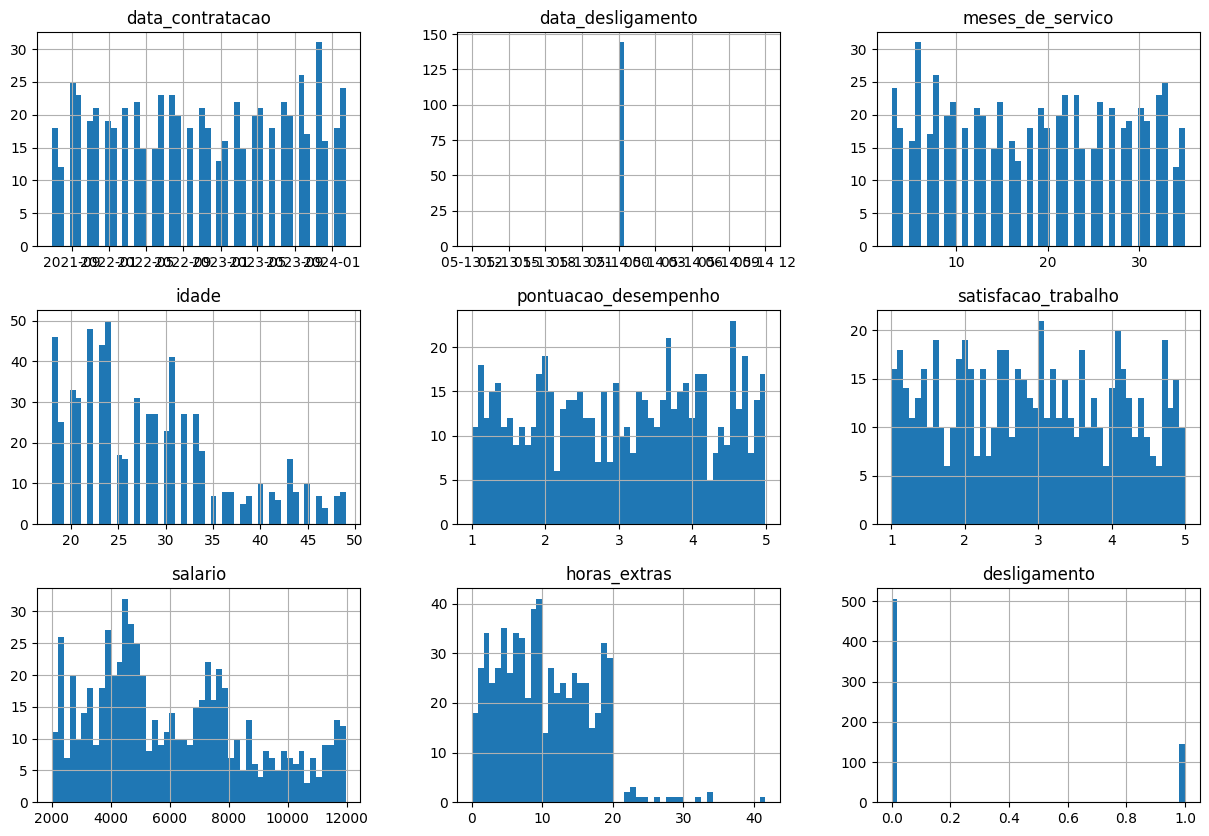

In [ ]:
df.hist(bins = 50, figsize=(15, 10))
plt.show()

In [ ]:
df.isnull().sum()

data_contratacao          0
data_desligamento       506
meses_de_servico          0
idade                     0
pontuacao_desempenho      0
satisfacao_trabalho       0
nivel_cargo               0
salario                   0
horas_extras              0
desligamento              0
dtype: int64

In [173]:
df.nivel_cargo.value_counts()

nivel_cargo
Junior    233
Pleno     225
Sênior    192
Name: count, dtype: int64

In [10]:
print('Data min de desligamento: ', df.data_desligamento.min())
print('Data max de desligamento: ', df.data_desligamento.max())

print('Data min de contratacao: ', df.data_contratacao.min())
print('Data max de contratacao: ', df.data_contratacao.max())

print('\nVerificando se existe algum registro com data de contratacao igual a dada de desligamento')
df.loc[df.data_desligamento == df.data_contratacao].shape

Data min de desligamento:  2024-05-14 00:00:00
Data max de desligamento:  2024-05-14 00:00:00
Data min de contratacao:  2021-06-29 00:00:00
Data max de contratacao:  2024-02-14 00:00:00

Verificando se existe algum registro com data de contratacao igual a dada de desligamento


(0, 10)

<Axes: xlabel='meses_de_servico', ylabel='data_contratacao'>

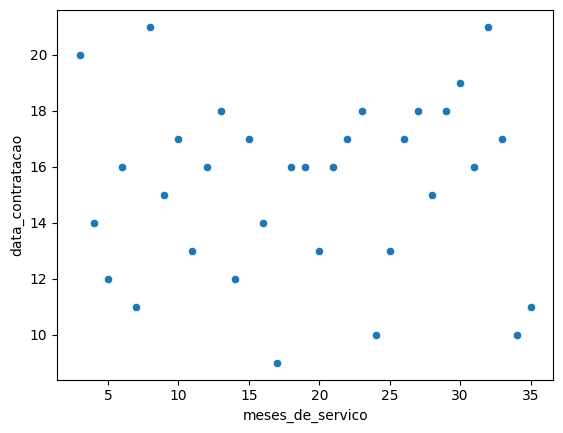

In [ ]:
service_fired = df.loc[df.desligamento == 0].groupby(['meses_de_servico']).data_contratacao.count().reset_index()

sns.scatterplot(data=service_fired,
                x = 'meses_de_servico',
                y = 'data_contratacao')

# <font color = 'gold'> Data Exploration </font>

In [ ]:
# quantidade de pessoas desligadas
# quantidade de pessoas contratadas

total_colaboradores = df.shape[0]
desligamentos = df.desligamento.sum()
colaboradores_ativos = total_colaboradores - desligamentos
turnover = ((total_colaboradores + desligamentos) / 2) / colaboradores_ativos

print('Taxa de turnover:', turnover)
print('Pessoas ativas: ', colaboradores_ativos)
print('Pessoas desligadas: ', desligamentos)

Taxa de turnover: 0.7845849802371542
Pessoas ativas:  506
Pessoas desligadas:  144


In [78]:
def taxa_retencao(df, by = []):
    total_colaboradores = df.shape[0]
    desligamentos = df.desligamento.sum()
    colaboradores_ativos = total_colaboradores - desligamentos 
    taxa_retencao_geral = colaboradores_ativos / total_colaboradores

    if not by: # checando se a lista está vazia
        return taxa_retencao_geral
    else:
        tx_retencao = df.groupby(by, observed=False).agg(total_colaboradores = ('data_contratacao', 'count'),
                              total_desligamentos = ('desligamento', 'sum')).reset_index()

        tx_retencao['colaboradores_ativos'] = tx_retencao.total_colaboradores - tx_retencao.total_desligamentos
        tx_retencao['taxa_retencao'] = tx_retencao.colaboradores_ativos / tx_retencao.total_colaboradores
        tx_retencao['turnover'] = ((tx_retencao.total_colaboradores + tx_retencao.total_desligamentos) / 2) / tx_retencao.colaboradores_ativos
        tx_retencao['comparacao_taxa_geral'] = (tx_retencao.taxa_retencao / taxa_retencao_geral - 1) * 100
        return tx_retencao

In [81]:
taxa_retencao(df, 'nivel_cargo')

,nivel_cargo,total_colaboradores,total_desligamentos,colaboradores_ativos,taxa_retencao,turnover,comparacao_taxa_geral
0,Junior,233,56,177,0.759657,0.816384,-2.415647
1,Pleno,225,45,180,0.800000,0.750000,2.766798
2,Sênior,192,43,149,0.776042,0.788591,-0.310853


In [43]:
labels = [1, 2, 3, 4]
bins = [0, 25, 30, 35, np.inf]

df['idade_group'] = pd.cut(df.idade, bins=bins, labels=labels)
df.head()

,data_contratacao,data_desligamento,meses_de_servico,idade,pontuacao_desempenho,satisfacao_trabalho,nivel_cargo,salario,horas_extras,desligamento,idade_group
0,2024-02-14,NaT,3,24,2.066788,2.043644,Pleno,4994.41,15.465241,0,1
1,2023-11-16,2024-05-14,6,43,3.256257,1.711719,Sênior,8798.34,19.036627,1,4
2,2023-11-16,NaT,6,45,4.827732,3.480214,Sênior,8891.02,13.326408,0,4
3,2023-05-20,NaT,12,31,1.453944,1.617558,Pleno,7606.22,14.209663,0,3
4,2022-07-24,NaT,22,37,2.088917,2.763390,Sênior,9236.03,11.059687,0,4


<Axes: >

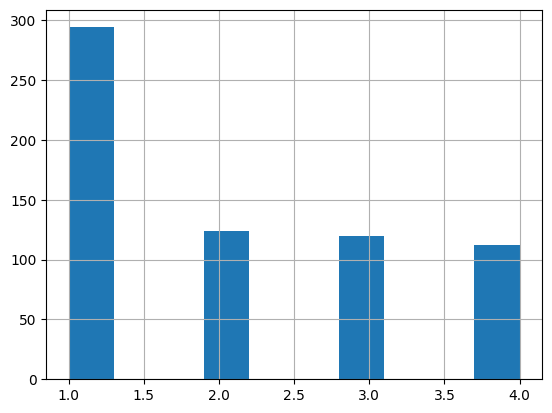

In [44]:
df.idade_group.hist()

In [62]:
taxa_retencao(df, 'idade_group')

,idade_group,total_colaboradores,total_desligamentos,colaboradores_ativos,taxa_retencao,turnover,comparacao_taxa_geral
0,1,294,64,230,0.782313,0.778261,0.494743
1,2,124,25,99,0.798387,0.752525,2.559607
2,3,120,27,93,0.775000,0.790323,-0.444664
3,4,112,28,84,0.750000,0.833333,-3.656126


<Axes: xlabel='idade_group', ylabel='comparacao_taxa_geral'>

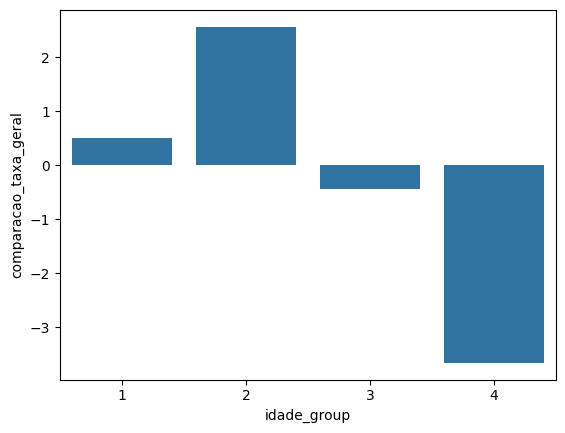

In [89]:
sns.barplot(taxa_retencao(df, 'idade_group'),
            x = 'idade_group',
            y = 'comparacao_taxa_geral')

In [66]:
df.meses_de_servico.describe()

count    650.000000
mean      18.690769
std        9.652262
min        3.000000
25%       10.000000
50%       19.000000
75%       27.000000
max       35.000000
Name: meses_de_servico, dtype: float64

<Axes: >

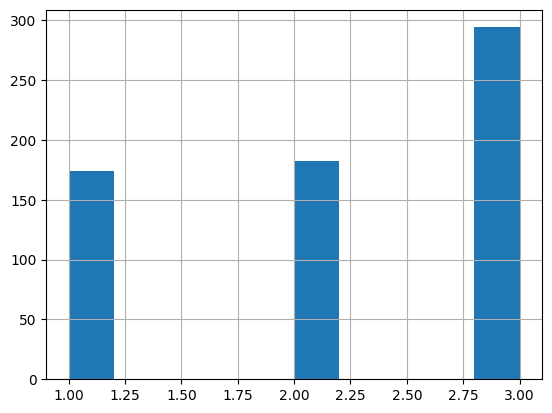

In [69]:
labels = [1, 2, 3]
bins = [0, 10, 20, np.inf]

df['meses_de_servico_group'] = pd.cut(x = df.meses_de_servico,
                                      bins = bins,
                                      labels = labels)
df.meses_de_servico_group.hist()

In [82]:
taxa_retencao(df, by = ['nivel_cargo', 'meses_de_servico_group'])

,nivel_cargo,meses_de_servico_group,total_colaboradores,total_desligamentos,colaboradores_ativos,taxa_retencao,turnover,comparacao_taxa_geral
0,Junior,1,67,25,42,0.626866,1.095238,-19.473777
1,Junior,2,67,12,55,0.820896,0.718182,5.451006
2,Junior,3,99,19,80,0.808081,0.737500,3.804847
3,Pleno,1,58,12,46,0.793103,0.760870,1.880878
4,Pleno,2,58,13,45,0.775862,0.788889,-0.333924
5,Pleno,3,109,20,89,0.816514,0.724719,4.888131
6,Sênior,1,49,11,38,0.775510,0.789474,-0.379124
7,Sênior,2,57,13,44,0.771930,0.795455,-0.839054
8,Sênior,3,86,19,67,0.779070,0.783582,0.078132


<Axes: xlabel='nivel_cargo', ylabel='salario'>

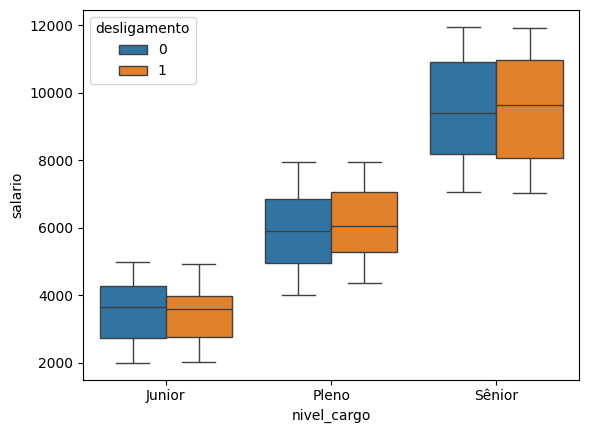

In [176]:
sns.boxplot(data = df,
            y = 'salario',
            x = 'nivel_cargo',
            hue = 'desligamento',
            order = ['Junior', 'Pleno', 'Sênior']
            )

In [37]:
df.head()

,data_contratacao,data_desligamento,meses_de_servico,idade,pontuacao_desempenho,satisfacao_trabalho,nivel_cargo,salario,horas_extras,desligamento
0,2024-02-14,NaT,3,24,2.066788,2.043644,Pleno,4994.41,15.465241,0
1,2023-11-16,2024-05-14,6,43,3.256257,1.711719,Sênior,8798.34,19.036627,1
2,2023-11-16,NaT,6,45,4.827732,3.480214,Sênior,8891.02,13.326408,0
3,2023-05-20,NaT,12,31,1.453944,1.617558,Pleno,7606.22,14.209663,0
4,2022-07-24,NaT,22,37,2.088917,2.763390,Sênior,9236.03,11.059687,0


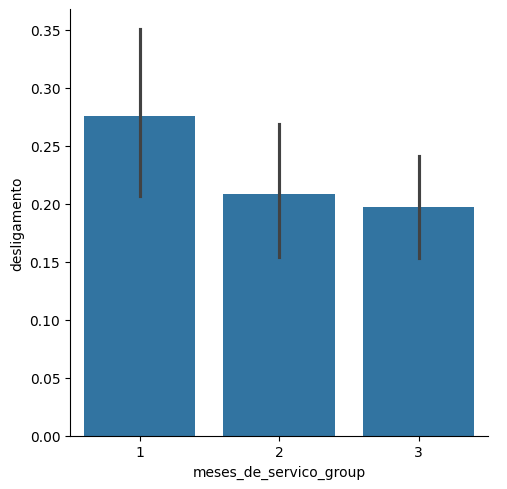

In [93]:
# Quanto maior a idade do funcionário, menor será a taxa de desligamento

sns.catplot(data = df, 
            x = 'meses_de_servico_group',
            y = 'desligamento',
            kind = 'bar')